
=== Comparison: Current Pmax vs Linear-corrected (Hs = H/1.4) ===
 Rank  H_m Pmax_current_Pa a_est_Pa_per_m Pmax_linear_corr_Pa Diff_percent
    1 1.14          48,129         42,218              34,378       -28.6%
    2 1.16          49,150         42,371              35,107       -28.6%
    3 1.19          50,677         42,586              36,198       -28.6%
    4 1.23          52,703         42,848              37,645       -28.6%
    5 1.30          56,219         43,246              40,157       -28.6%

Mean percent difference: -28.6%


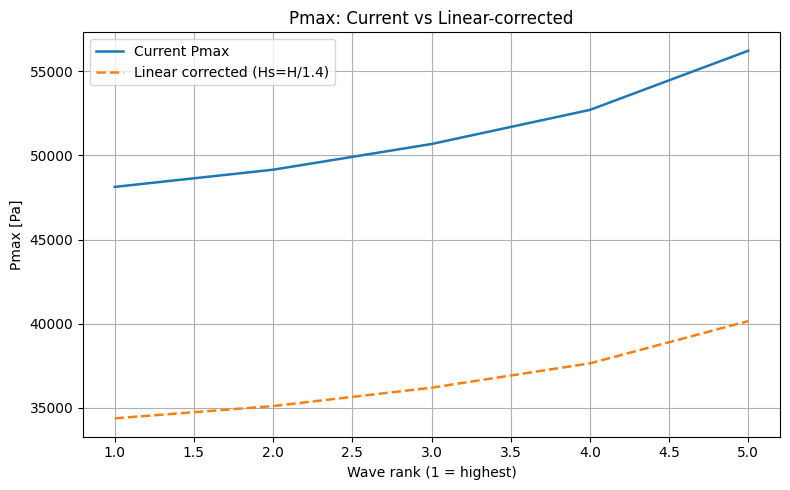

In [2]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------
# INPUT PARAMETERS
# ------------------------
Hs_input = 0.7          # Significant wave height you currently use
rho_w = 1025.0          # Water density [kg/m3]
g = 9.81                # Gravity [m/s2]
Tp = 5.59               # Peak period [s]
tan_beta = 1.0 / 3.0    # Slope
n = 1000                # Total number of waves in the Rayleigh distribution
top_n = 5               # How many top waves to test

# ------------------------
# Generate top N waves from Rayleigh distribution
# ------------------------
p_values = [(k + 1) / float(n + 1) for k in range(top_n)]  # exceedance probs
wave_heights = sorted([round(Hs_input * np.sqrt(0.5 * np.log(1.0 / p)), 2) for p in p_values])

# ------------------------
# Compare current vs corrected Pmax
# ------------------------
rows = []
for i, H_wave in enumerate(wave_heights):
    # Calculate breaker parameter ξ
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)

    # Current method Pmax
    denom = (xi - 0.2)**2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    Pmax_current = P_dimless * rho_w * g * H_wave

    # Linear "a" based on current method (accidentally using H instead of Hs)
    a_est = Pmax_current / H_wave  # Pa/m

    # Corrected method using Hs = H/1.4
    Pmax_linear_corr = a_est * (H_wave / 1.4)

    diff_pct = 100.0 * (Pmax_linear_corr - Pmax_current) / Pmax_current

    rows.append([i+1, H_wave, Pmax_current, a_est, Pmax_linear_corr, diff_pct])

# ------------------------
# Make dataframe
# ------------------------
comp_df = pd.DataFrame(rows, columns=[
    "Rank", "H_m", "Pmax_current_Pa", "a_est_Pa_per_m", "Pmax_linear_corr_Pa", "Diff_percent"
])

# ------------------------
# Print results
# ------------------------
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 10)
print("\n=== Comparison: Current Pmax vs Linear-corrected (Hs = H/1.4) ===")
print(comp_df.to_string(index=False, 
    formatters={
        "H_m": lambda v: "{:.2f}".format(v),
        "Pmax_current_Pa": lambda v: "{:,.0f}".format(v),
        "a_est_Pa_per_m": lambda v: "{:,.0f}".format(v),
        "Pmax_linear_corr_Pa": lambda v: "{:,.0f}".format(v),
        "Diff_percent": lambda v: "{:.1f}%".format(v)
    }))

print("\nMean percent difference: {:.1f}%".format(comp_df["Diff_percent"].mean()))

# ------------------------
# Plot comparison
# ------------------------
plt.figure(figsize=(8,5))
plt.plot(comp_df["Rank"], comp_df["Pmax_current_Pa"], label="Current Pmax", linewidth=1.8)
plt.plot(comp_df["Rank"], comp_df["Pmax_linear_corr_Pa"], label="Linear corrected (Hs=H/1.4)", linewidth=1.8, linestyle="--")
plt.xlabel("Wave rank (1 = highest)")
plt.ylabel("Pmax [Pa]")
plt.title("Pmax: Current vs Linear-corrected")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



=== Pmax comparison ===
 Rank H_wave_current_m Pmax_current_Pa Pmax_corrected_Pa H_wave_manual_m Pmax_manual_Pa
    1            1.140          48,129            34,378           1.630         49,154
    2            1.160          49,150            35,107           1.660         50,240
    3            1.190          50,677            36,198           1.700         51,711
    4            1.230          52,703            37,645           1.760         53,866
    5            1.300          56,219            40,157           1.860         57,455


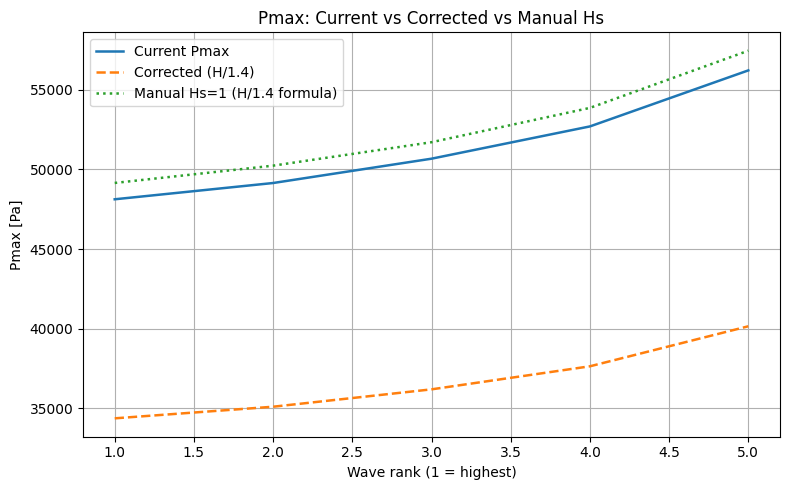

In [7]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------
# INPUT PARAMETERS
# ------------------------
Hs_input = 0.7           # Hs currently used in code (for current method)
Hs_manual = 1         # Hs you want to test manually for the third line
rho_w = 1025.0           # Water density [kg/m3]
g = 9.81                 # Gravity [m/s2]
Tp = 5.59                # Peak period [s]
tan_beta = 1.0 / 3.0     # Slope
n = 1000                 # Total number of waves in the Rayleigh distribution
top_n = 5                # How many top waves to test

# ------------------------
# Helper function to generate wave heights from Rayleigh distribution
# ------------------------
def generate_top_waves(Hs, top_n, n_total):
    p_values = [(k + 1) / float(n_total + 1) for k in range(top_n)]
    return sorted([round(Hs * np.sqrt(0.5 * np.log(1.0 / p)), 2) for p in p_values])

# ------------------------
# Get wave heights for each case
# ------------------------
wave_heights_current = generate_top_waves(Hs_input, top_n, n)
wave_heights_manual  = generate_top_waves(Hs_manual, top_n, n)

rows = []
for i in range(top_n):
    # ------------------------
    # CURRENT METHOD (physical formula)
    # ------------------------
    H_wave_current = wave_heights_current[i]
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi_current = tan_beta / np.sqrt(H_wave_current / L_m_1_0)
    denom_current = (xi_current - 0.2)**2
    P_dimless_current = 8.0 - 1.6 * xi_current - 2.0 / denom_current
    Pmax_current = P_dimless_current * rho_w * g * H_wave_current

    # Slope coefficient a from current method
    a_est = Pmax_current / H_wave_current

    # ------------------------
    # CORRECTED METHOD (line 2) with Hs = H/1.4
    # ------------------------
    Pmax_corrected = a_est * (H_wave_current / 1.4)

    # ------------------------
    # MANUAL Hs TEST (line 3) using same linear formula as corrected
    # ------------------------
    H_wave_manual = wave_heights_manual[i]
    Pmax_manual = a_est * (H_wave_manual / 1.4)

    rows.append([
        i+1,
        H_wave_current,
        Pmax_current,
        Pmax_corrected,
        H_wave_manual,
        Pmax_manual
    ])

# ------------------------
# Make dataframe
# ------------------------
comp_df = pd.DataFrame(rows, columns=[
    "Rank", "H_wave_current_m", "Pmax_current_Pa", "Pmax_corrected_Pa",
    "H_wave_manual_m", "Pmax_manual_Pa"
])

# ------------------------
# Print results
# ------------------------
pd.set_option('display.width', 160)
print("\n=== Pmax comparison ===")
print(comp_df.to_string(index=False, 
    formatters={
        "H_wave_current_m": lambda v: "{:.3f}".format(v),
        "Pmax_current_Pa": lambda v: "{:,.0f}".format(v),
        "Pmax_corrected_Pa": lambda v: "{:,.0f}".format(v),
        "H_wave_manual_m": lambda v: "{:.3f}".format(v),
        "Pmax_manual_Pa": lambda v: "{:,.0f}".format(v)
    }))

# ------------------------
# Plot comparison
# ------------------------
plt.figure(figsize=(8,5))
plt.plot(comp_df["Rank"], comp_df["Pmax_current_Pa"], label="Current Pmax", linewidth=1.8)
plt.plot(comp_df["Rank"], comp_df["Pmax_corrected_Pa"], label="Corrected (H/1.4)", linewidth=1.8, linestyle="--")
plt.plot(comp_df["Rank"], comp_df["Pmax_manual_Pa"], label=f"Manual Hs={Hs_manual} (H/1.4 formula)", linewidth=1.8, linestyle=":")

plt.xlabel("Wave rank (1 = highest)")
plt.ylabel("Pmax [Pa]")
plt.title("Pmax: Current vs Corrected vs Manual Hs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



=== Pmax comparison ===
 Rank H_wave_current_m Pmax_current_Pa Pmax_corrected_Pa H_wave_manual_m Pmax_manual_Pa Tp_sop_s Pmax_sop_Pa
    1            1.140          48,129            34,378           1.220         36,790     4.27      50,660
    2            1.160          49,150            35,107           1.250         37,831     4.31      51,549
    3            1.190          50,677            36,198           1.280         38,935     4.37      52,882
    4            1.230          52,703            37,645           1.320         40,399     4.44      54,659
    5            1.300          56,219            40,157           1.390         42,937     4.56      57,770


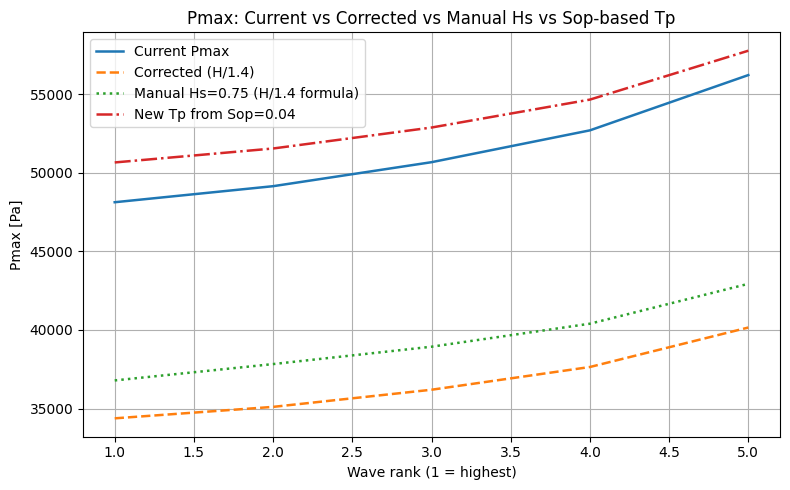

In [8]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------
# INPUT PARAMETERS
# ------------------------
Hs_input = 0.7           # Hs currently used in code (for current method)
Hs_manual = 0.75         # Hs you want to test manually for the third line
Sop = 0.04               # Wave steepness for fourth line Tp calculation
rho_w = 1025.0           # Water density [kg/m3]
g = 9.81                 # Gravity [m/s2]
Tp_default = 5.59        # Peak period [s] (current method)
tan_beta = 1.0 / 3.0     # Slope
n = 1000                 # Total number of waves in the Rayleigh distribution
top_n = 5                # How many top waves to test

# ------------------------
# Helper function to generate wave heights from Rayleigh distribution
# ------------------------
def generate_top_waves(Hs, top_n, n_total):
    p_values = [(k + 1) / float(n_total + 1) for k in range(top_n)]
    return sorted([round(Hs * np.sqrt(0.5 * np.log(1.0 / p)), 2) for p in p_values])

# ------------------------
# Get wave heights for each case
# ------------------------
wave_heights_current = generate_top_waves(Hs_input, top_n, n)
wave_heights_manual  = generate_top_waves(Hs_manual, top_n, n)

rows = []
for i in range(top_n):
    # ------------------------
    # CURRENT METHOD (physical formula)
    # ------------------------
    H_wave_current = wave_heights_current[i]
    Tm_1_0 = Tp_default / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi_current = tan_beta / np.sqrt(H_wave_current / L_m_1_0)
    denom_current = (xi_current - 0.2)**2
    P_dimless_current = 8.0 - 1.6 * xi_current - 2.0 / denom_current
    Pmax_current = P_dimless_current * rho_w * g * H_wave_current

    # Slope coefficient a from current method
    a_est = Pmax_current / H_wave_current

    # ------------------------
    # CORRECTED METHOD (line 2) with Hs = H/1.4
    # ------------------------
    Pmax_corrected = a_est * (H_wave_current / 1.4)

    # ------------------------
    # MANUAL Hs TEST (line 3) using same linear formula as corrected
    # ------------------------
    H_wave_manual = wave_heights_manual[i]
    Pmax_manual = a_est * (H_wave_manual / 1.4)

    # ------------------------
    # FOURTH LINE: New Tp from Sop
    # ------------------------
    # Calculate Tp from Sop = Hs / Lp  →  Lp = Hs / Sop
    Lp_sop = H_wave_current / Sop
    Tp_sop = np.sqrt((2.0 * np.pi * Lp_sop) / g)

    Tm_1_0_sop = Tp_sop / 1.1
    L_m_1_0_sop = (g * Tm_1_0_sop**2) / (2.0 * np.pi)
    xi_sop = tan_beta / np.sqrt(H_wave_current / L_m_1_0_sop)
    denom_sop = (xi_sop - 0.2)**2
    P_dimless_sop = 8.0 - 1.6 * xi_sop - 2.0 / denom_sop
    Pmax_sop = P_dimless_sop * rho_w * g * H_wave_current

    rows.append([
        i+1,
        H_wave_current,
        Pmax_current,
        Pmax_corrected,
        H_wave_manual,
        Pmax_manual,
        Tp_sop,
        Pmax_sop
    ])

# ------------------------
# Make dataframe
# ------------------------
comp_df = pd.DataFrame(rows, columns=[
    "Rank", "H_wave_current_m", "Pmax_current_Pa", "Pmax_corrected_Pa",
    "H_wave_manual_m", "Pmax_manual_Pa", "Tp_sop_s", "Pmax_sop_Pa"
])

# ------------------------
# Print results
# ------------------------
pd.set_option('display.width', 200)
print("\n=== Pmax comparison ===")
print(comp_df.to_string(index=False, 
    formatters={
        "H_wave_current_m": lambda v: "{:.3f}".format(v),
        "Pmax_current_Pa": lambda v: "{:,.0f}".format(v),
        "Pmax_corrected_Pa": lambda v: "{:,.0f}".format(v),
        "H_wave_manual_m": lambda v: "{:.3f}".format(v),
        "Pmax_manual_Pa": lambda v: "{:,.0f}".format(v),
        "Tp_sop_s": lambda v: "{:.2f}".format(v),
        "Pmax_sop_Pa": lambda v: "{:,.0f}".format(v)
    }))

# ------------------------
# Plot comparison
# ------------------------
plt.figure(figsize=(8,5))
plt.plot(comp_df["Rank"], comp_df["Pmax_current_Pa"], label="Current Pmax", linewidth=1.8)
plt.plot(comp_df["Rank"], comp_df["Pmax_corrected_Pa"], label="Corrected (H/1.4)", linewidth=1.8, linestyle="--")
plt.plot(comp_df["Rank"], comp_df["Pmax_manual_Pa"], label=f"Manual Hs={Hs_manual} (H/1.4 formula)", linewidth=1.8, linestyle=":")
plt.plot(comp_df["Rank"], comp_df["Pmax_sop_Pa"], label=f"New Tp from Sop={Sop}", linewidth=1.8, linestyle="-.")

plt.xlabel("Wave rank (1 = highest)")
plt.ylabel("Pmax [Pa]")
plt.title("Pmax: Current vs Corrected vs Manual Hs vs Sop-based Tp")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
